In [15]:
import sys
sys.path.append("/nfs/roberts/project/pi_sk2433/tl855/PointCloudNet/")

import torch
import pathlib
from models.graph_learning import HiPoNet, MLPAutoEncoder
from utils.read_data import load_data
import phate
import scprep
import numpy as np
import pickle

In [9]:
# PCs, labels, num_labels = load_data(
#     "/home/tl855/project_pi_sk2433/shared/Hiren_2025_HiPoNet/pdo_data/", ""
# )
# precomputed_embeddings = torch.load(
#     "/home/tl855/project_pi_sk2433/tl855/PointCloudNet/data/precomputed_embeddings/pdo_data_emb.pt"
# )
# precomputed_labels = torch.load(
#     "/home/tl855/project_pi_sk2433/tl855/PointCloudNet/data/precomputed_embeddings/pdo_data_label.pt"
# )
# label_names = np.load("/home/tl855/project_pi_sk2433/shared/Hiren_2025_HiPoNet/pdo_data/labels_pdo_treatment.npy")
# # Note: np.unique does not preserve order, but in this case it does since labels appear alphabetically
# label_names = np.unique(label_names)

# [l.item() for l in labels] == [l.item() for l in precomputed_labels]

dataset = "COVID_data"
precomputed_embeddings = torch.load(
    f"/home/tl855/project_pi_sk2433/tl855/PointCloudNet/data/precomputed_embeddings/{dataset}_emb.pt"
)
labels = np.load("/nfs/roberts/project/pi_sk2433/shared/Hiren_2025_HiPoNet/covid/COVID_data/labels.npy")[:, None]

In [34]:
with open(
    "/nfs/roberts/project/pi_sk2433/shared/Hiren_2025_HiPoNet/covid/COVID_data/filtered_point_cloud_labels_final.pickle",
    "rb",
) as f:
    labels = np.array(list(pickle.load(f).values()))[:, None]

In [5]:
slurm_job_id = "2665846"
weights = torch.load(f"../model_weights/{slurm_job_id}/autoencoder.pt", map_location="cpu")
autoencoder = MLPAutoEncoder(
    input_dim=precomputed_embeddings.shape[1],
    hidden_dim=1024,
    embedding_dim=4,
    num_layers=3,
)
autoencoder.load_state_dict(weights)
with torch.no_grad():
    autoenc_embeddings = autoencoder.encode(precomputed_embeddings)

In [7]:
phate_dim, phate_knn = 2, 25
label_col = 0
discrete = (label_col == 0)
cmap = "viridis" if not discrete else "tab10"

/home/tl855/project_pi_sk2433/tl855/PointCloudNet/.venv/lib/python3.11/site-packages/graphtools/graphs.py:473: UserWarning: Building a kNNGraph on data of shape torch.Size([78, 700]) is expensive. Consider setting n_pca.
  warnings.warn(
/home/tl855/project_pi_sk2433/tl855/PointCloudNet/.venv/lib/python3.11/site-packages/graphtools/graphs.py:625: RuntimeWarning: Detected zero distance between 19 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


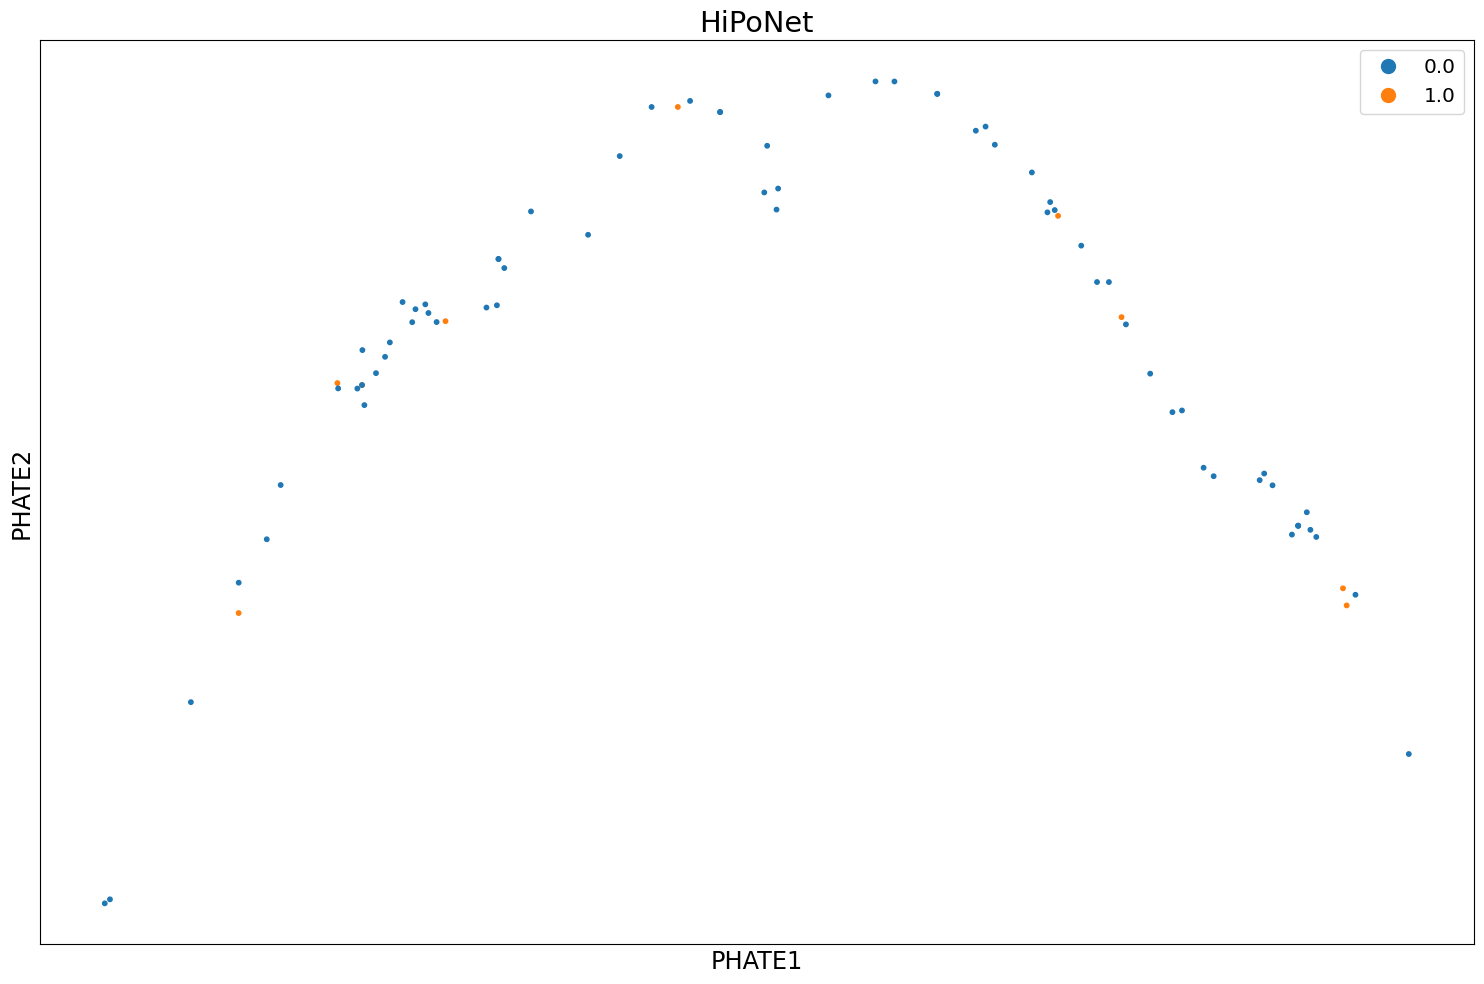

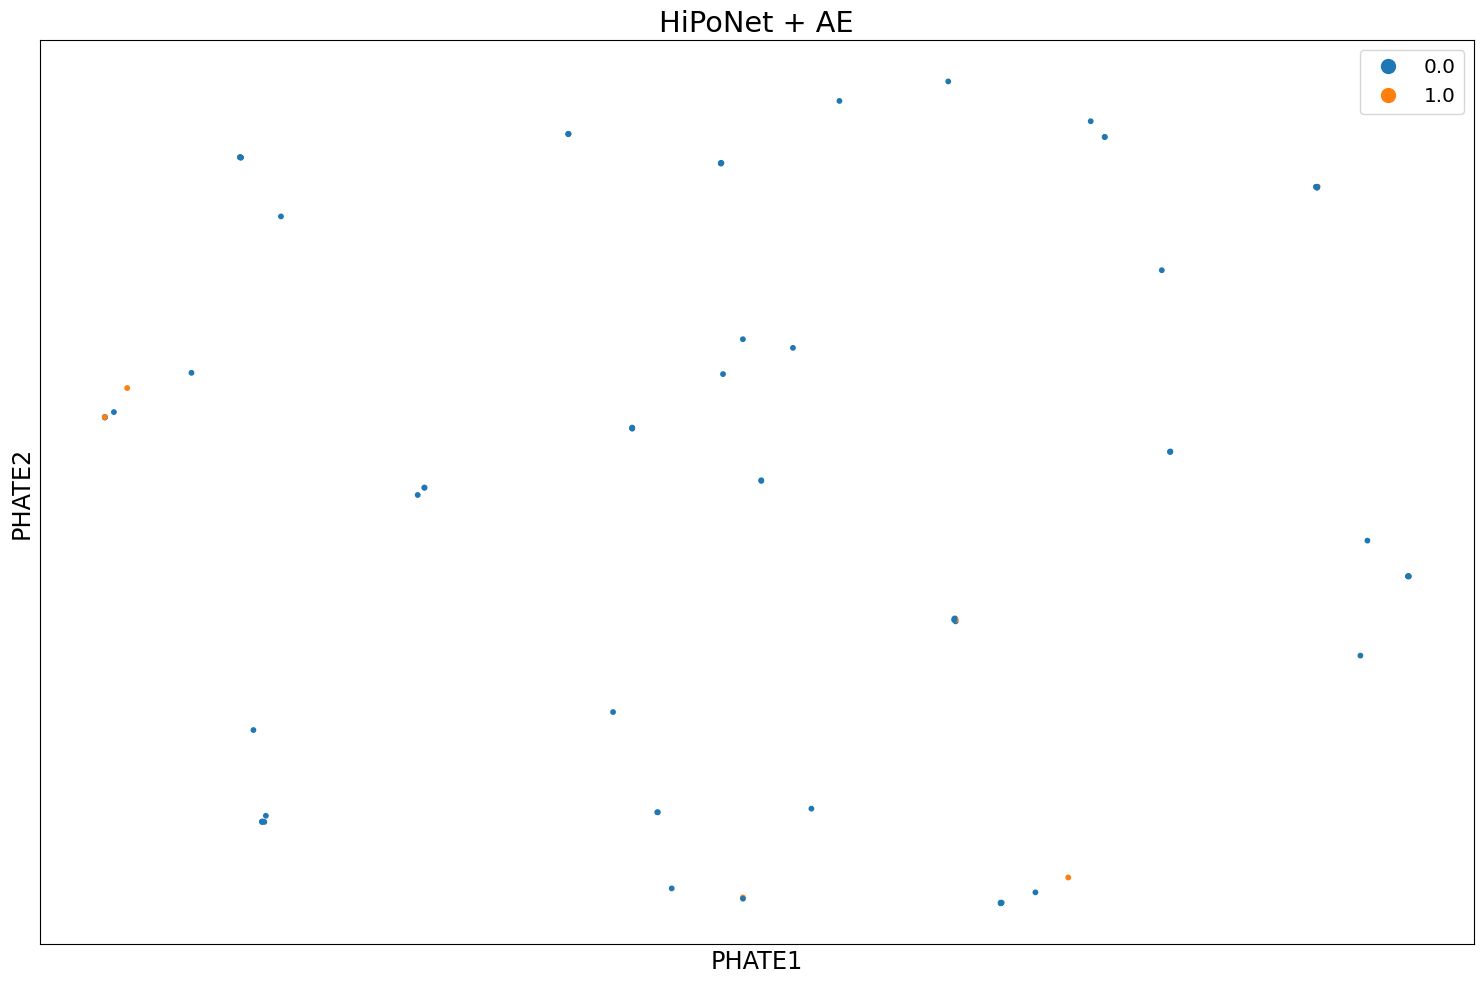

In [35]:
hipo_phate_op = phate.PHATE(n_components=phate_dim, knn=phate_knn, verbose=0)
hipo_phate_coords = hipo_phate_op.fit_transform(precomputed_embeddings )

ax = scprep.plot.scatter2d(
    hipo_phate_coords,
    c=labels[:, label_col],
    cmap=cmap,
    s=10,
    figsize=(15,10),
    ticks=None,
    label_prefix="PHATE",
    fontsize=12,
    legend=True,
    discrete=discrete,
    title="HiPoNet",
)

ae_phate_op = phate.PHATE(n_components=phate_dim, knn=phate_knn, verbose=0)
ae_phate_coords = ae_phate_op.fit_transform(autoenc_embeddings)

ax = scprep.plot.scatter2d(
    ae_phate_coords,
    c=labels[:, label_col],
    cmap=cmap,
    s=10,
    figsize=(15,10),
    ticks=None,
    label_prefix="PHATE",
    fontsize=12,
    legend=True,
    discrete=discrete,
    title="HiPoNet + AE",
)